<!--NOTEBOOK_HEADER-->
*This notebook contains material from [PyRosetta](https://RosettaCommons.github.io/PyRosetta.notebooks);
content is available [on Github](https://github.com/RosettaCommons/PyRosetta.notebooks.git).*
This notebook was developed based on the original notebook by Andrei Sokolovskii (andrei.sokolovskii@vub.be)

## The Heatmap
We will learn how to perform in silico mutational scanning to generate a heatmap like the one below.

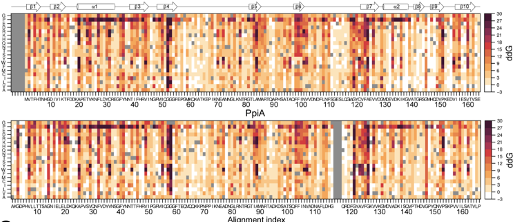

## Introduction.

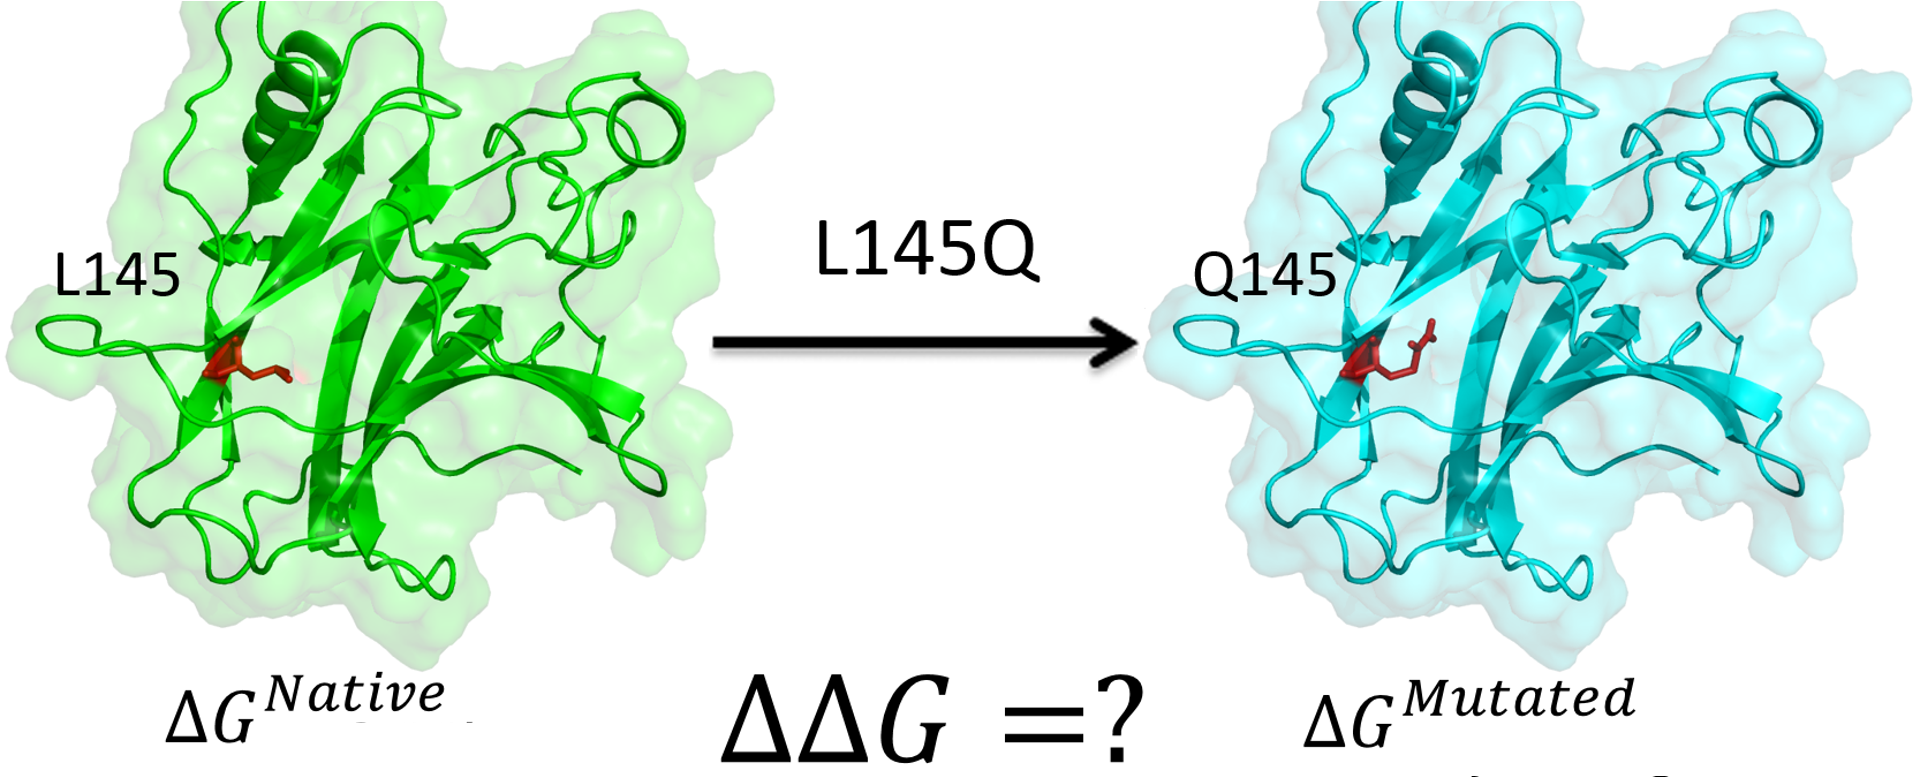

Accurately estimating the thermodynamic effect of a mutation is a key to protein engineering and design. In this exercise, we will scan all possible permutations in a small protein to try to find stabilizing mutations. To achieve this, we will carry out "alchemical" mutations during simulations and compute the corresponding free energy changes. By computing the folding free energy of the wild type protein and each mutant, we can assess the effect of mutations by substracting theyr folding free energy from that of the wild type, as shown below:

$$
\begin{align}
\Large {\Delta}{\Delta}G = {\Delta}G_{fold_{MT}} - {\Delta}G_{fold_{  WT}}
\end{align}
$$

## Objectives
1. Setup parameters
2. Prepare files and relax the PDB structure
3. Compute the ∆∆G of mutation
4. Analyze contributions to the change in stability
5. Visualize the model in PyMOL

### <u>How to load a module</u> :
- Click on **Software** on the left tab, underneath the folder explorer
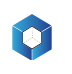
- Type the name of the packages and click on load
- Wait for the module to be load before loading another module 
    
The module are loaded for whole session of the notebook.  
After loading all of the module, to be able to import it you have to restart the ipikernel. You can click on:
- **Python 3 (ipykernel) | Idle** on the bottom left of the screen
- Choose the correct python environment : **Python 3 (ipykernel** 
- And press select 
    
### <u>Module to load by hand</u>
Proper work with the notebook requires the following modules:
1. PyRosetta/4.release-384-gompi-2022a
2. SciPy-bundle/2022.05-foss-2022a
3. matplotlib/3.5.2-foss-2022a
4. Seaborn/0.12.1-foss-2022a

In [1]:
import os
import glob
import numpy as np
import logging
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

%matplotlib inline

In [2]:
import pyrosetta

In [ ]:
#Set here the current working directory
import os
cwd = os.getcwd()
current_dir=cwd+"/practicals_protein_design/mutations_ddg/"

In [3]:
pyrosetta.init("-mute all -out:path:pdb '/data/brussel/vo/000/bvo00014/practicals_protein_design/mutations_ddg/' ")

┌──────────────────────────────────────────────────────────────────────────────┐
│                                 PyRosetta-4                                  │
│              Created in JHU by Sergey Lyskov and PyRosetta Team              │
│              (C) Copyright Rosetta Commons Member Institutions               │
│                                                                              │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRE PURCHASE OF A LICENSE │
│         See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└──────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2024 [Rosetta PyRosetta4.Release.python311.linux 2024.39+release.59628fbc5bc09f1221e1642f1f8d157ce49b1410 2024-09-23T07:49:48] retrieved from: http://www.pyrosetta.org


## Preparation of the files 

At this moment the following file structure should be present:
- ddG_notebook.ipynb
- PDB_filename.pdb

## Relaxation
The structure must be **relaxed** before it can be used for free energy calculations. Relaxing means minimizng the energy by sidechains repacking and backbone minimzation (simulated annealing) to make sure the input structure represents the lowest energy state. We will use coordinate retraints to make sure the output structure is almost identical to the input PDB structure. Typically, this step requires running several independent trajectories and picking the lowest energy output. 



In [13]:
pose = pyrosetta.pose_from_pdb( current_dir+"peptide.pdb")

In [16]:
relaxPose = pose.clone()
xml = pyrosetta.rosetta.protocols.rosetta_scripts.XmlObjects.create_from_string("""
    <ROSETTASCRIPTS>
        <SCOREFXNS>
        <ScoreFunction name="SFX1" weights="ref2015_cart">
           <Reweight scoretype="coordinate_constraint" weight="1.0"/>
        </ScoreFunction>
        </SCOREFXNS>
        <RESIDUE_SELECTORS>
        </RESIDUE_SELECTORS>
        <TASKOPERATIONS>
        </TASKOPERATIONS>
        <FILTERS>
        </FILTERS>
        <MOVERS>
           <AtomCoordinateCstMover name="coord_cst" />
           <FastRelax name="relax" cartesian="true" scorefxn="SFX1" />
        </MOVERS>
        <APPLY_TO_POSE/>
        <PROTOCOLS>
           <Add mover="coord_cst"/>
           <Add mover="relax" />
        </PROTOCOLS>
    </ROSETTASCRIPTS>
    """).get_mover("ParsedProtocol")
xml.apply(relaxPose)
relaxPose.dump_pdb(current_dir+'relaxed_peptide_with_cst.pdb')

True

## Scoring
Let's compare the calculated energy (score) of the relaxed structure to the input PDB.

In [17]:
scorefxn = pyrosetta.get_score_function()
print("\nOld Energy:", scorefxn(pose),"\n")
print("\nNew Energy:", scorefxn(relaxPose),"\n")



Old Energy: 44.130352106670685 


New Energy: -45.38584586722844 



## Mutfile's preparation
We obtain the relaxed protein structure that is now prepared for mutational scanning.

We have to create new subfolders for each mutation, each containing a __mutfile__
<br><br>

Each __mutfile__ consists the following lines:

total 1 &emsp;# this is the total number of mutations being made.
<br>
1 &emsp; &emsp;&emsp;#the number of mutations
<br>
G 1 A &emsp; # the wild-type aa, the residue number, and the mutant aa


In the list below, add or remove positions to mutate and amino acids to mutated them to

In [19]:
mut = ['L1', 'Y2', 'I3', 'Q4', 'W5', 'L6', 'K7', 'D8']
aa_list = ['M', 'F','G', 'A', 'I', 'P', 'S']

In [21]:
import shutil
import os

#conf.back() 
mutations = []

for aa in range(0, len(mut)):
    pos = mut[aa]
    AA = mut[aa][0]
    if not os.path.exists(current_dir+"mutations/"+pos):
        os.makedirs(current_dir+"mutations/"+pos)
    for m in aa_list:
        if m != AA:
            mutation = pos+m
            mutations.append(mutation)
            if not os.path.exists(current_dir+"mutations/"+pos+"/"+mutation):
                os.makedirs(current_dir+"mutations/"+pos+"/"+mutation)
            with open(current_dir+"mutations/"+pos+"/"+mutation+"/mutfile",'w') as mut_file:
                mut_file.write("total 1\n")
                mut_file.write("1\n")
                mut_file.write("%s %d %s\n" %(AA, int(mut[aa][1:]), m))

#The code below copies your relaxed pdb into the mutations folder. You can change the name of the relaxed pdb if needed
shutil.copyfile(current_dir+'relaxed_peptide.pdb', current_dir+'mutations/relaxed_peptide.pdb')


'/data/brussel/vo/000/bvo00014/practicals_protein_design/mutations_ddg/mutations/relaxed_peptide.pdb'

The __jobname__ folder structure now is looking like this:

- __jobname__
    - PDB_filename_clean.pdb
    - __$i^{th}$ trajectory folder__
        - stdout.txt
        - PDB_filename_*.pdb
        - PDB_filename.fasc
    - __mutations__
        - relaxed_PDB_filename_clean_$i$.pdb
        - __$i^{th}$__ mutation folder along __mut__ array
            - __$j^{th}$__ resulted mut folder along __aa_list__
                - mutfile


## ${\Delta}{\Delta} G$ calculation
In the next cell we will initialize two funciton.

def __ddg_job__ is made for estimating $\Delta\Delta G$ per one-point mutation. 

def __run_ddg_calc_parallel__ is wrapper function for running calculation in parallel.

In [31]:
class configs(object):
  def __init__(self):

    self.PDB_filename = current_dir+'mutations/relaxed_peptide.pdb'
    self.mut = ['L1', 'Y2', 'I3', 'Q4', 'W5', 'L6', 'K7', 'D8']
    self.aa_list = ['M', 'F','G', 'A', 'I', 'P', 'S']
    self.jobname = 'jobname_peptide'
    
    self.num_threads = 5
    self.ntraj = 20
    self.nstruct = 2
    self.relax_scorefxn = 'ref2015_cart'
    self.ddg_iterations = 3
    self.force_iterations = False
    self.ddg_score_cutoff = 1.0
    self.ddg_dump_pdbs = True
    self.ddg_bbnbrs = 1
    self.fa_max_dis = 9.0
    self.ddg_scorefxn = 'ref2015_cart'
    
    if not os.path.exists(self.PDB_filename):
        raise Exception(f"Sorry, the file with name {self.PDB_filename[:-4]} was not found.")
    
    if self.num_threads == 0: 
        nslots = int(os.environ['SLURM_CPUS_PER_TASK'])
        self.num_threads = nslots
    self.coord_cst = True
    py_flags = "-ddg:mut_file mutfile -ddg:iterations "
    py_flags += str(self.ddg_iterations) 
    py_flags += " -force_iterations "
    py_flags += str(self.force_iterations).lower()
    py_flags += " -ddg::score_cutoff "
    py_flags += str(self.ddg_score_cutoff)
    py_flags += " -ddg::cartesian -ddg::dump_pdbs "
    py_flags += str(self.ddg_dump_pdbs).lower()
    py_flags += " -ddg:bbnbrs "
    py_flags += str(self.ddg_bbnbrs)
    py_flags += " -fa_max_dis "
    py_flags += str(self.fa_max_dis)
    py_flags += " -score:weights "
    py_flags += str(self.ddg_scorefxn)
    py_flags += ".wts"
    self.py_flags = py_flags
#    self.working_dir = os.getcwd()
    self.working_dir = current_dir #"/data/brussel/104/vsc10411/practicals_protein_design/mutations_ddg"
    
  def back(self):
        os.chdir(self.working_dir)
    
conf = configs()

In [42]:
def ddg_job(args):
    pdb_name, py_flags, dest = args
    print(pdb_name, py_flags, dest)
    os.chdir(dest)
    print(os.getcwd())
    logging.basicConfig(filename=current_dir+'stdout.txt', level=logging.INFO)

#    pose = pyrosetta.pose_from_pdb(current_dir+'../../' + pdb_name)
    pose = pyrosetta.pose_from_pdb(pdb_name)
    pyrosetta.rosetta.protocols.ddg.CartesianddG.run(pose)
    os.chdir(current_dir+'../../')
    return 0

def run_ddg_calc_parallel(conf):
    conf.back() 
#    os.chdir(f'mutations')
    name = conf.PDB_filename

    num_th = conf.num_threads
    args = [(name, conf.py_flags, x[:-7]) for x in glob.glob(current_dir+'mutations/*/*/mutfile')]
    pyrosetta.init(conf.py_flags)
    with Pool(num_th) as pool:
        pool.map(ddg_job, args, chunksize=1)
    os.chdir(current_dir+'../../')
    return 0


Now, we will run $\Delta\Delta G$ calculation for all one-point mutations that were selected in __config__ class.

In [ ]:
from multiprocessing.pool import Pool

run_ddg_calc_parallel(conf)

Let's analyze just generated outputs. We are intrested in __mutfile.ddg__  files.

The __jobname__ folder structure now is looking like this:

- __jobname__
    - PDB_filename_clean.pdb
    - __$i^{th}$ trajectory folder__
        - stdout.txt
        - PDB_filename_*.pdb
        - PDB_filename.fasc
    - __mutations__
        - relaxed_PDB_filename_clean_$i$.pdb
        - __$i^{th}$__ mutation folder along __mut__ array
            - __$j^{th}$__ resulted mut folder along __aa_list__
                - mutfile
                - mutfile.ddg
                - stdout.txt
    
Based on the information from __mutfile.ddg__, the $\Delta\Delta G$ will be calculated as follows:

$$
\begin{align}
\Large{\Delta}{\Delta}G={\frac {\sum_{i}^{} MUT\_total\_score_{i} \\}{ddg\_iterations} }-{\frac {\sum_{i}^{} WT\_total\_score_{i} \\}{ddg\_iterations} }
\end{align}
$$


## Analyzing 
The bellow function generates __*.csv__ file in root directory with $\Delta\Delta G$ values measured in REU. Today, we won't run this scriipt because we probably have not had the time to process all the mutations. Instead, go to the next cell to work with a pre-computed result file.

In [46]:
os.chdir(current_dir+'../../')

In [49]:
def analyze_ssm(conf):
#    conf.back()
    mut = conf.mut
    aa_list = conf.aa_list
    import os
    import glob
    import numpy as np
    mut_dir=current_dir+"mutations/"
    def nice_order(aa_l):
        nice_order_for_heatmap  = ["G","P","E","D","R","K","H","Q","N","T","S","Y","W","F","M","C","I","L","V","A"]
        aa_list_for_an = nice_order_for_heatmap.copy()
        for item in nice_order_for_heatmap:
            if item not in aa_l:
                aa_list_for_an.remove(item)
        return aa_list_for_an
    aa_list = nice_order(aa_list)
    ala_scan = {}
    ssm = np.zeros([len(aa_list), len(mut)], dtype=float)
    pdb_name = mut_dir+"relaxed_peptide"

    for aa in range(0, len(mut)):
        pos = mut[aa]
        AA = mut[aa][0]
        for i in range(0, len(aa_list)):
            amino_acid = aa_list[i]
            if AA != amino_acid:
                mutation = mut[aa]+amino_acid
                n_WT = 0
                n_MUT = 0
                score_WT = 0
                score_MUT = 0
                with open(mut_dir+pos+"/"+mutation+"/mutfile.ddg", 'r') as mutfile:
                    for line in mutfile:
                        if "WT" in line:
                            score = float(line.split()[3])
                            n_WT += 1
                            score_WT += score
                        elif "MUT_" in line:
                            score = float(line.split()[3])
                            n_MUT += 1
                            score_MUT += score
                score_WT = score_WT/n_WT
                score_MUT = score_MUT/n_MUT
                ddG = score_MUT - score_WT
                ssm[i,aa] = float(ddG)


    np.savetxt(mut_dir+"SSM_ddg_peptide.csv", ssm, delimiter=",")
#    os.chdir('../../')
    return 0
analyze_ssm(conf)

0

Once the *SSM_ddg.csv* file is obtained, we can finally plot heatmap and detect which mutation and where could stabilize the protein.

In [51]:
ssm_file=current_dir+"precomputed_results/SSM_ddg_peptide.csv"

In [52]:
mut = ['L1', 'Y2', 'I3', 'Q4', 'W5', 'L6', 'K7', 'D8']
aa_list = ['M','F','Y','V','L','W','G','A','I','P','S','T','Q','N','R','K','E','D','C','H']

In [ ]:
def plot_heatmap(ssm_file):
    def nice_order(aa_l):
        nice_order_for_heatmap  = ["G","P","E","D","R","K","H","Q","N","T","S","Y","W","F","M","C","I","L","V","A"]
        aa_list_for_an = nice_order_for_heatmap.copy()
        for item in nice_order_for_heatmap:
            if item not in aa_l:
                aa_list_for_an.remove(item)
        return aa_list_for_an
    a_list = nice_order(aa_list)
    print(a_list)
    df_ddg = pd.read_csv(ssm_file, header=None)    
    rows = {i:a_list[i] for i in range(len(a_list))}
    columns = {i:mut[i] for i in range(len(mut))}
    
    df_ddg = df_ddg.rename(columns=columns)
    df_ddg = df_ddg.rename(index=rows)
    minc = df_ddg.min().min()
    range_color = [minc, (-1.5) * minc]
    sns.set (rc = {'figure.figsize':(15, 10)})
    ax = sns.heatmap(df_ddg, cmap="Greys", annot=True, fmt=".1f",linewidth=.5, vmin = minc, vmax = (-1.5) * minc, \
                     cbar_kws={'label': 'ΔΔG', 'orientation': 'vertical'})#, annot_kws={"size": 20}
    ax.set(xlabel="Mutations", ylabel="Amino Acid")
    ax.xaxis.tick_top()
    
plot_heatmap(ssm_file)


You can change the color and looks of the heatmap by looking in the pyplot documentation for the right commands:
https://matplotlib.org/stable/users/explain/colors/colormaps.html

**Bonus: visualize proteins in the notebook instead of Pymol**


You will need to load the following module (left)

py3Dmol/2.0.1.post1-GCCcore-11.3.0

In [62]:
### Excercise 2.2.1 Visualize Chains with different colours of chains 159, 1 ,  51
import py3Dmol
view=py3Dmol.view()
conf.back()
print(os.getcwd())
view.addModel(open(current_dir+'peptide.pdb', 'r').read(),'pdb')
view.addModel(open(current_dir+'relaxed_peptide.pdb', 'r').read(),'pdb')
view.zoomTo()
view.setBackgroundColor('white')
view.setStyle({'chain':'A'},{'cartoon': {'color':'skyblue'}})
view.setStyle({'chain':'B'},{'cartoon': {'color':'yellow'}})
#view.addStyle({'chain':'B'},{'stick':{'color':'skyblue'}})
#view.setStyle({'chain':'B'},{'cartoon': {'color':'yellow'},'stick': {'color':'skyblue'} })
view.addStyle({'chain':'B','resi':50 + 12},{'stick':{'color':'red'}})
view.addStyle({'chain':'B','resi':50 + 15},{'stick':{'color':'red'}})
view.addStyle({'chain':'B','resi':50 + 19},{'stick':{'color':'red'}})
view.addLabel("L169",{'fontOpacity':1},{'chain':'B','resi':50 + 12})
view.addLabel("I172",{'fontOpacity':1},{'chain':'B','resi':50 + 15})
view.addLabel("F176",{'fontOpacity':1},{'chain':'B','resi':50 + 19})
view.show()

/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00014/practicals_protein_design/mutations_ddg


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## ΔΔG Part 2: interaction free energy calculations (protein complex)

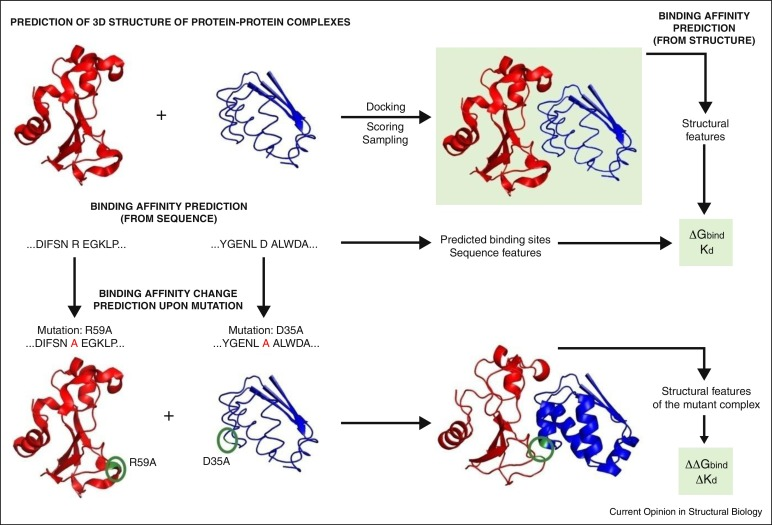

Image taken from: https://doi.org/10.1016/j.sbi.2016.10.016

*This section is adapted from the Pyrosetta teaching notebooks, developed by Yuanhan Wu (The Wistar Institute), Daniel Kulp (The Wistar Institute), Jared Adolf-Bryfogle (Scripps; Institute for Protein Innovation) and Ajasja Ljubetič (University of Washington)*

Another important problem in protein engineering is how to accurately estimate the effect of mutations on the interaction energy of two proteins. For example, considering a peptide binding to your protein of interest, you might want to predict which mutations in the peptide would result in stronger or weaker binding.

The principle of the interaction free energy calculations is similar to the principles outlined above. We are now considering the **binding free energy**, which is the difference between the individual free energies of the free interaction partners and the total energy of the complex according to the equation below. Starting from the PDB structure of the complex, we compute its total energy. The proteins in the complex are then pull apart to calculate the sum of their individual energies. The same simulations are used to calculate the binding free energy of the complex in the presence of  mutations. The final ΔΔG*binding* is the **difference in binding free energy of the WT complex and the mutated complex**.

$$
\begin{align}
\Large {\Delta}{\Delta}G = ∑{\Delta}G_{monomers} - {\Delta}G_{complex}
\end{align}
$$

Our model system will be GLP-1 (Glucagon-Like peptide 1). It is a hormone that plays a crucial role in regulating blood sugar and appetite. It's produced in the small intestine and stimulates insulin release from the pancreas, helping to lower blood sugar levels after eating. GLP-1 also slows down digestion and can help reduce appetite. Its natural binding partner is the Glucagon-Like Peptide-1 (GLP-1) Receptor, a GPCR. The recently developed weight loss blockbuster drugs (e.g. Ozempic) are engineered peptides that act like GLP-1 receptor agonists and mimick the effects of GLP-1. GLP-1 and its receptors are therefore very important drug development targets.

In [58]:
#@title Let's skip to long relax and load the relaxed pose
pose_glp = pyrosetta.pose_from_pdb(current_dir+"precomputed_results/GLP_complex.relax.pdb")

In [59]:
#@title Here is a function to separate the two chains in the complex and computing the interaction energy

def unbind(pose, partners):
    STEP_SIZE = 100
    JUMP = 1
    pyrosetta.rosetta.protocols.docking.setup_foldtree(pose, partners, pyrosetta.Vector1([-1,-1,-1]))
    trans_mover = pyrosetta.rosetta.protocols.rigid.RigidBodyTransMover(pose,JUMP)
    trans_mover.step_size(STEP_SIZE)
    trans_mover.apply(pose)


##Reset the original pose
relaxPose = pyrosetta.pose_from_pdb(current_dir+"precomputed_results/GLP_complex.relax.pdb")
original = relaxPose.clone()

scorefxn = pyrosetta.get_score_function()
bound_score = scorefxn(relaxPose)
print("\nBound State Score",bound_score,"\n")
unbind(original, "A_B")
unbound_score = scorefxn(original)
original.dump_pdb(current_dir+'GLP_unbound.pdb')

print("\nUnbound State Score", unbound_score,"\n")
print('dG', bound_score - unbound_score, 'Rosetta Energy Units (REU)')


Bound State Score -1338.5536630426132 


Unbound State Score -1171.5496706711533 

dG -167.00399237145984 Rosetta Energy Units (REU)


In [63]:
show_sidechains = True #@param {type:"boolean"}
color = "chain" #@param ["chain", "rainbow"]
model = "bound" #@param ["bound", "unbound"]

view=py3Dmol.view()

def show_pdb(show_sidechains=False, color="chain", model="bound"):

  if model == "bound":
    view.addModel(open(current_dir+'precomputed_results/'+'GLP_complex.relax.pdb', 'r').read(),'pdb')
  elif model == "unbound":
    view.addModel(open(current_dir+'precomputed_results/'+'GLP_unbound.pdb', 'r').read(),'pdb')

  view.setBackgroundColor('white')

  if color == "rainbow":
    view.setStyle({'cartoon': {'color':'spectrum'}})
  elif color == "chain":
    chains = pose_glp.num_chains()#len(queries[0][1]) + 1 if is_complex else 1
    pymol_color_list = ['skyblue', 'yellow', 'green', 'magenta', 'white', 'salmon']
    alphabet_list = ['A', 'B', 'C', 'D', 'E', 'F']

    for n,chain,color in zip(range(chains),alphabet_list,pymol_color_list):
      view.setStyle({'chain':chain},{'cartoon': {'color':color}})


  if show_sidechains:
    BB = ['C','O','N']
    view.addStyle({'and':[{'resn':["GLY","PRO"],'invert':True},{'atom':BB,'invert':True}]},
                        {'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
    view.addStyle({'and':[{'resn':"GLY"},{'atom':'CA'}]},
                        {'sphere':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
    view.addStyle({'and':[{'resn':"PRO"},{'atom':['C','O'],'invert':True}]},
                        {'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})

  view.zoomTo()
  return view

show_pdb(show_sidechains, color, model).show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

DDG Calculations will be very long for this system. We will skip and look at final results. Open the complex structure in PyMol and try to find interesting patterns linking the structure and the heatmap below

In [ ]:
ssm_file_GLP=current_dir+"precomputed_results/SSM_ddg_GLP.csv"
plot_heatmap(ssm_file_GLP)